In [1]:
import torch
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the directory in Google Drive where you saved the tensors
save_dir = '/content/drive/MyDrive/saved_tensors'

# 3. Load the tensors
test_tensor = torch.load(os.path.join(save_dir, 'train_tensor.pt'))
train_tensor = torch.load(os.path.join(save_dir, 'test_tensor.pt'))
val_tensor = torch.load(os.path.join(save_dir, 'val_tensor.pt'))

print("Tensors loaded successfully!")
print(f"train_tensor shape: {train_tensor.shape}")
print(f"test_tensor shape: {test_tensor.shape}")
print(f"val_tensor shape: {val_tensor.shape}")

Mounted at /content/drive
Tensors loaded successfully!
train_tensor shape: torch.Size([12236, 253, 128])
test_tensor shape: torch.Size([5841, 253, 128])
val_tensor shape: torch.Size([3494, 253, 128])


In [4]:
!pip install torch torchvision torchaudio tqdm

In [60]:
import math
import torch
import torch.nn as nn
from typing import Optional
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
        self.d_model = d_model
        self.max_len = max_len

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)

        # If sequence is longer than pre-computed, compute on-the-fly
        if seq_len > self.max_len:
            position = torch.arange(self.max_len, seq_len, device=x.device).unsqueeze(1)
            div_term = torch.exp(torch.arange(0, self.d_model, 2, device=x.device) *
                               (-math.log(10000.0) / self.d_model))
            pe_extra = torch.zeros(seq_len - self.max_len, self.d_model, device=x.device)
            pe_extra[:, 0::2] = torch.sin(position * div_term)
            pe_extra[:, 1::2] = torch.cos(position * div_term)
            pe_extra = pe_extra.unsqueeze(0)
            pe_full = torch.cat([self.pe, pe_extra], dim=1)
        else:
            pe_full = self.pe[:, :seq_len, :]

        x = x + pe_full
        return self.dropout(x)

In [61]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention with causal masking support."""
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1, causal: bool = True):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.causal = causal

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        b, L, _ = x.shape

        # Linear projections
        Q = self.W_q(x).view(b, L, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(b, L, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(b, L, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply causal mask (lower triangular)
        if self.causal:
            causal_mask = torch.triu(torch.ones(L, L, device=x.device), diagonal=1).bool()
            scores = scores.masked_fill(causal_mask, float("-inf"))

        # Apply additional mask if provided
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(b, L, self.d_model)
        return self.W_o(out)


In [62]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network."""
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


In [63]:
class TransformerBlock(nn.Module):
    """Transformer block with causal attention."""
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1, causal: bool = True):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout, causal=causal)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        attn_out = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


In [64]:
class AutoregressiveTransformer(nn.Module):
    """
    Autoregressive Transformer for audio frame prediction.

    Architecture:
    - Uses causal masking (can only see past frames)
    - Predicts one frame at a time
    - Can generate variable number of frames at inference

    Training: Uses teacher forcing (predicts next frame given previous frames)
    Inference: Generates autoregressively (each prediction uses previous predictions)
    """
    def __init__(
        self,
        input_dim: int,  # Frequency bins (128)
        d_model: int,
        num_heads: int,
        num_layers: int,
        d_ff: int,
        max_seq_len: int = 300,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model

        # Input embedding
        self.input_embedding = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        # Transformer blocks with causal masking
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout, causal=True)
            for _ in range(num_layers)
        ])

        # Output projection: predicts one frame at a time
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, input_dim),  # Output one frame (input_dim values)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for training (teacher forcing).

        Args:
            x: Input of shape (batch, seq_len, input_dim)
               During training: [context + target] frames
               Model predicts each frame given all previous frames

        Returns:
            Predictions of shape (batch, seq_len, input_dim)
            Each position predicts the NEXT frame
        """
        b, L, _ = x.shape

        # Embed and add positional encoding
        x = self.input_embedding(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)

        # Apply transformer blocks with causal masking
        for layer in self.layers:
            x = layer(x)  # Causal masking applied inside

        # Project to output (one frame per position)
        out = self.output_proj(x)  # (batch, seq_len, input_dim)

        return out

    def generate(self, context: torch.Tensor, num_frames: int = 10) -> torch.Tensor:
        """
        Autoregressive generation at inference.

        Args:
            context: Initial context of shape (batch, context_len, input_dim)
            num_frames: Number of frames to generate

        Returns:
            Generated frames of shape (batch, num_frames, input_dim)
        """
        self.eval()
        batch_size = context.shape[0]
        device = context.device

        # Start with context
        generated = context.clone()

        with torch.no_grad():
            for _ in range(num_frames):
                # Get predictions for the entire sequence
                predictions = self.forward(generated)  # (batch, seq_len, input_dim)

                # Take the last prediction (next frame)
                next_frame = predictions[:, -1:, :]  # (batch, 1, input_dim)

                # Append to generated sequence
                generated = torch.cat([generated, next_frame], dim=1)

        # Return only the newly generated frames
        return generated[:, -num_frames:, :]


In [7]:
def normalize_tensors(train_tensor, val_tensor, test_tensor, method='standardize'):
    """
    Normalize log mel spectrograms from [-10, 0] range to [-1, 1] or [0, 1].
    """
    if method == 'standardize':
        train_mean = train_tensor.mean()
        train_std = train_tensor.std()
        train_norm = (train_tensor - train_mean) / train_std
        val_norm = (val_tensor - train_mean) / train_std
        test_norm = (test_tensor - train_mean) / train_std
        stats = {'mean': train_mean, 'std': train_std, 'method': 'standardize'}
    elif method == 'minmax':
        train_min = train_tensor.min()
        train_max = train_tensor.max()
        train_norm = (train_tensor - train_min) / (train_max - train_min + 1e-8)
        val_norm = (val_tensor - train_min) / (train_max - train_min + 1e-8)
        test_norm = (test_tensor - train_min) / (train_max - train_min + 1e-8)
        stats = {'min': train_min, 'max': train_max, 'method': 'minmax'}
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    print(f"Normalization ({method}):")
    print(f"  Train: min={train_norm.min():.4f}, max={train_norm.max():.4f}, mean={train_norm.mean():.4f}, std={train_norm.std():.4f}")
    print(f"  Val:   min={val_norm.min():.4f}, max={val_norm.max():.4f}, mean={val_norm.mean():.4f}, std={val_norm.std():.4f}")

    return train_norm, val_norm, test_norm, stats


In [8]:
MODEL_CONFIGS = {
    "small": dict(
        d_model=128,
        num_heads=4,
        num_layers=2,
        d_ff=512,
    ),
    "medium": dict(
        d_model=256,
        num_heads=8,
        num_layers=4,
        d_ff=1024,
    ),
    "large": dict(
        d_model=512,
        num_heads=16,
        num_layers=8,
        d_ff=2048,
    ),
}

In [9]:
from torch.utils.data import Dataset, DataLoader
class AutoregressiveDataset(Dataset):
    """
    Dataset for autoregressive training.

    For each sample:
    - Input: [context + target] frames (for teacher forcing)
    - Target: Shifted version (each position predicts next frame)

    Example with context_size=50, target_frames=5:
    - Input: frames [0:55] (50 context + 5 target)
    - Target: frames [1:56] (shifted by 1, so each position predicts next)
    """
    def __init__(
        self,
        data: torch.Tensor,
        context_size: int,
        target_frames: int = 5,  # Number of target frames to include
        stride: int = 5,
    ):
        super().__init__()
        assert data.ndim == 3
        self.data = data
        self.context_size = context_size
        self.target_frames = target_frames
        self.stride = stride

        N, T, _ = data.shape
        self.indices = []

        for n in range(N):
            # Need context_size + target_frames + 1 (for shift)
            max_start = T - (context_size + target_frames + 1)
            for start_t in range(0, max_start + 1, stride):
                self.indices.append((n, start_t))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        n, start_t = self.indices[idx]
        seq = self.data[n]

        # Input: [context + target] frames
        # For teacher forcing: model sees both context and target
        input_end = start_t + self.context_size + self.target_frames
        input_seq = seq[start_t:input_end]  # (context_size + target_frames, F)

        # Target: Shifted by 1 (each position predicts next frame)
        # This is the standard autoregressive setup
        target_seq = seq[start_t + 1:input_end + 1]  # (context_size + target_frames, F)

        return input_seq, target_seq


In [ ]:
# from torch.utils.data import Dataset, DataLoader


# class TensorWindowDataset(Dataset):
#     """
#     Wraps a tensor of shape (N, T, F) and turns it into
#     many (context, target) pairs using a sliding window.
#     """

#     def __init__(
#         self,
#         data: torch.Tensor,           # (N, T, F)
#         context_size: int,
#         prediction_horizon: int,
#         stride: int = 1,
#     ):
#         super().__init__()
#         assert data.ndim == 3
#         self.data = data
#         self.context_size = context_size
#         self.prediction_horizon = prediction_horizon
#         self.stride = stride

#         N, T, _ = data.shape
#         self.indices = []  # list of (n_idx, start_t)

#         for n in range(N):
#             max_start = T - (context_size + prediction_horizon)
#             for start_t in range(0, max_start + 1, stride):
#                 self.indices.append((n, start_t))

#     def __len__(self):
#         return len(self.indices)

#     def __getitem__(self, idx):
#         n, start_t = self.indices[idx]
#         end_context = start_t + self.context_size
#         end_target = end_context + self.prediction_horizon

#         seq = self.data[n]  # (T, F)
#         context = seq[start_t:end_context]        # (context_size, F)
#         target = seq[end_context:end_target]      # (prediction_horizon, F)

#         return context, target  # both (seq_len, input_dim)

In [10]:
from torch.utils.data import Dataset, DataLoader
def create_dataloaders_from_tensors(
    train_tensor: torch.Tensor,
    val_tensor: torch.Tensor,
    test_tensor: torch.Tensor,
    context_size: int,
    target_frames: int = 5,  # Frames to include in training sequence
    batch_size: int = 64,
    stride: int = 5,
    num_workers: int = 2,
):
    train_ds = AutoregressiveDataset(train_tensor, context_size, target_frames, stride)
    val_ds = AutoregressiveDataset(val_tensor, context_size, target_frames, stride)
    test_ds = AutoregressiveDataset(test_tensor, context_size, target_frames, stride)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, test_loader


In [ ]:
from tqdm import tqdm


def train_one_epoch(model, loader, criterion, optimizer, device, gradient_clip=1.0):
    """Training with teacher forcing."""
    model.train()
    total_loss = 0.0
    for input_seq, target_seq in tqdm(loader, desc="Train", leave=False):
        input_seq = input_seq.to(device)  # (batch, seq_len, input_dim)
        target_seq = target_seq.to(device)  # (batch, seq_len, input_dim)

        optimizer.zero_grad()

        # Forward pass: model predicts each position given previous positions
        predictions = model(input_seq)  # (batch, seq_len, input_dim)

        # Loss: compare predictions to shifted targets
        loss = criterion(predictions, target_seq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip)
        optimizer.step()

        total_loss += loss.item() * input_seq.size(0)
    return total_loss / len(loader.dataset)



def eval_one_epoch(model, loader, criterion, device, desc="Val", return_metrics=False,
                   context_size=None, target_frames=None, use_autoregressive=True):
    """
    Validation/Testing.

    Args:
        use_autoregressive: If True, use model.generate() (matches test time).
                           If False, use model() with teacher forcing (old behavior).
        context_size: Required if use_autoregressive=True
        target_frames: Required if use_autoregressive=True (number of frames to generate)
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for input_seq, target_seq in tqdm(loader, desc=desc, leave=False):
            input_seq = input_seq.to(device)
            target_seq = target_seq.to(device)

            if use_autoregressive and context_size is not None and target_frames is not None:
                # ✅ FIXED: Use autoregressive generation (matches test time)
                # input_seq contains [context, target] concatenated (frames 0-251)
                # We only use the context part for generation (frames 0-149)
                context = input_seq[:, :context_size, :]  # Only context frames (0-149)
                
                # ✅ CRITICAL FIX: Generate only target_frames (102), not all frames (252)
                # target_seq.shape[1] = 252 (wrong!), we need target_frames = 102
                num_frames = target_frames  # Generate 102 frames, not 252

                # Generate autoregressively (like test time)
                # This generates frames 150-251 (102 frames)
                predictions = model.generate(context, num_frames=num_frames)
                
                # ✅ CRITICAL FIX: Extract correct target from input_seq (frames 150-251)
                # Not target_seq which is shifted (frames 1-252)
                target = input_seq[:, context_size:context_size + target_frames, :]
            else:
                # Old behavior: teacher forcing (sees full sequence)
                predictions = model(input_seq)
                target = target_seq

            loss = criterion(predictions, target)
            total_loss += loss.item() * input_seq.size(0)

            if return_metrics:
                all_preds.append(predictions.cpu())
                all_targets.append(target.cpu())

    avg_loss = total_loss / len(loader.dataset)

    if return_metrics:
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        # MAE
        mae = torch.mean(torch.abs(all_preds - all_targets)).item()

        # R² Score
        ss_res = torch.sum((all_targets - all_preds) ** 2)
        ss_tot = torch.sum((all_targets - torch.mean(all_targets)) ** 2)
        r2 = (1 - ss_res / (ss_tot + 1e-8)).item()

        # Correlation
        pred_flat = all_preds.flatten()
        target_flat = all_targets.flatten()
        pred_centered = pred_flat - torch.mean(pred_flat)
        target_centered = target_flat - torch.mean(target_flat)
        correlation = (torch.sum(pred_centered * target_centered) /
                      (torch.sqrt(torch.sum(pred_centered ** 2) * torch.sum(target_centered ** 2)) + 1e-8)).item()

        return avg_loss, {"mae": mae, "r2": r2, "correlation": correlation}

    return avg_loss



In [ ]:
import os
def train_autoregressive_transformer(
    train_tensor,
    val_tensor,
    test_tensor,
    model_sizes=('small','medium','large'),
    context_size=50,
    target_frames=5,  # Frames to include in training sequence
    batch_size=64,
    num_epochs=20,
    learning_rate=1e-3,
    weight_decay=1e-5,
    save_dir="checkpoints_autoregressive",
    stride=5,
    gradient_clip=1.0,
    filename_tag: str = '',
    normalize_method='standardize',
):
    """
    Train autoregressive transformer models.

    Key differences from non-autoregressive:
    - Uses causal masking (can only see past)
    - Predicts one frame at a time
    - Can generate variable number of frames at inference
    """
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Normalize data
    print("\n" + "="*60)
    print("STEP 1: NORMALIZING DATA")
    print("="*60)
    print(f"Original data stats:")
    print(f"  Train: min={train_tensor.min():.4f}, max={train_tensor.max():.4f}, mean={train_tensor.mean():.4f}")

    train_tensor_norm, val_tensor_norm, test_tensor_norm, norm_stats = normalize_tensors(
        train_tensor, val_tensor, test_tensor, method=normalize_method
    )

    torch.save(norm_stats, os.path.join(save_dir, "normalization_stats.pt"))
    print(f"✅ Normalization stats saved")

    # Create dataloaders
    print("\n" + "="*60)
    print("STEP 2: CREATING DATALOADERS")
    print("="*60)
    train_loader, val_loader, test_loader = create_dataloaders_from_tensors(
        train_tensor_norm, val_tensor_norm, test_tensor_norm,
        context_size=context_size,
        target_frames=target_frames,
        batch_size=batch_size,
        stride=stride,
        num_workers=2,
    )

    print(f"Train batches: {len(train_loader):,} (samples: {len(train_loader.dataset):,})")
    print(f"Val batches:   {len(val_loader):,} (samples: {len(val_loader.dataset):,})")
    print(f"Test batches:  {len(test_loader):,} (samples: {len(test_loader.dataset):,})")

    input_dim = train_tensor.shape[-1]

    # Train each model size
    for size in model_sizes:
        print("\n" + "="*60)
        print(f"TRAINING AUTOREGRESSIVE TRANSFORMER ({size.upper()})")
        print("="*60)

        cfg = MODEL_CONFIGS[size]
        model = AutoregressiveTransformer(
            input_dim=input_dim,
            d_model=cfg["d_model"],
            num_heads=cfg["num_heads"],
            num_layers=cfg["num_layers"],
            d_ff=cfg["d_ff"],
            max_seq_len=context_size + target_frames+10,
            dropout=0.1,
        ).to(device)

        param_count = sum(p.numel() for p in model.parameters())
        print(f"Model parameters: {param_count:,}")
        print(f"Architecture: Autoregressive with causal masking")
        print(f"Training: Teacher forcing (predicts next frame given previous)")
        print(f"Inference: Can generate any number of frames")

        criterion = nn.MSELoss()
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=learning_rate, weight_decay=weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )

        best_val = float("inf")
        best_path = os.path.join(save_dir, f"autoregressive_{size}_{context_size}_{target_frames}_modified_params_3.pt")

        print(f"\nTraining configuration:")
        print(f"  Learning rate: {learning_rate}")
        print(f"  Stride: {stride}")
        print(f"  Gradient clip: {gradient_clip}")
        print(f"  Context size: {context_size}")
        print(f"  Target frames: {target_frames}")

        for epoch in range(1, num_epochs + 1):
            print(f"\nEpoch {epoch}/{num_epochs}")

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, device, gradient_clip
            )

            val_loss, val_metrics = eval_one_epoch(
                model, val_loader, criterion, device, desc="Val", return_metrics=True,
                context_size=context_size, target_frames=target_frames, use_autoregressive=True  # ✅ Use autoregressive for realistic validation
            )

            scheduler.step(val_loss)
            current_lr = optimizer.param_groups[0]['lr']

            print(f"  Train Loss: {train_loss:.6f}")
            print(f"  Val Loss:   {val_loss:.6f}")
            print(f"  Val MAE:    {val_metrics['mae']:.6f}")
            print(f"  Val R²:     {val_metrics['r2']:.4f}")
            print(f"  Val Corr:   {val_metrics['correlation']:.4f}")
            print(f"  LR:         {current_lr:.2e}")

            if val_loss < best_val:
                best_val = val_loss
                checkpoint = {
                    "model_state_dict": model.state_dict(),
                    "config": {
                        "size": size,
                        "input_dim": input_dim,
                        "context_size": context_size,
                        "target_frames": target_frames,
                        "normalization_stats": norm_stats,
                        "autoregressive": True,
                        **cfg,
                    },
                    "val_loss": val_loss,
                    "epoch": epoch,
                }
                torch.save(checkpoint, best_path)
                print(f"  Saved best model (val_loss: {val_loss:.6f})")

        # Final test evaluation
        test_loss, test_metrics = eval_one_epoch(
            model, test_loader, criterion, device, desc="Test", return_metrics=True,
            context_size=context_size, target_frames=target_frames, use_autoregressive=True  # ✅ Use autoregressive (matches test evaluation)
        )
        print(f"\n[{size.upper()}] Final Results:")
        print(f"  Test Loss:      {test_loss:.6f}")
        print(f"  Test MAE:       {test_metrics['mae']:.6f}")
        print(f"  Test R²:        {test_metrics['r2']:.4f}")
        print(f"  Test Corr:      {test_metrics['correlation']:.4f}")
        print(f"  Best Val Loss:  {best_val:.6f}")
        print(f"  Model saved to: {best_path}")


In [66]:
# train_autoregressive_transformer(
#     train_tensor=train_tensor,
#     val_tensor=val_tensor,
#     test_tensor=test_tensor,
#     model_sizes=("large",),  # Train one at a time
#     context_size=150,
#     target_frames=102,  # Frames to include in training sequence
#     batch_size=32,
#     num_epochs=25,
#     learning_rate=1e-4,
#     weight_decay=1e-4,
#     stride=5,
#     gradient_clip=.5,
#     save_dir="checkpoints_autoregressive",
# )

train_autoregressive_transformer(
    train_tensor=train_tensor,
    val_tensor=val_tensor,
    test_tensor=test_tensor,
    model_sizes=("small",),    # Changed to small
    context_size=150,
    target_frames=102,
    batch_size=64,             # ✅ Larger batch (small model can handle it)
    num_epochs=35,             # As requested
    learning_rate=8e-4,         # ✅ Higher LR (small model less sensitive)
    weight_decay=2e-5,          # ✅ Less regularization (small model doesn't overfit much)
    stride=5,
    gradient_clip=1.0,          # ✅ Standard clipping (small model is stable)
    save_dir="checkpoints_autoregressive",
)

Using device: cuda

STEP 1: NORMALIZING DATA
Original data stats:
  Train: min=-11.5129, max=6.2508, mean=-2.4923
Normalization (standardize):
  Train: min=-2.6938, max=2.6109, mean=0.0000, std=1.0000
  Val:   min=-2.6938, max=2.5461, mean=-0.0603, std=0.7413
✅ Normalization stats saved

STEP 2: CREATING DATALOADERS
Train batches: 192 (samples: 12,236)
Val batches:   55 (samples: 3,494)
Test batches:  92 (samples: 5,841)

TRAINING AUTOREGRESSIVE TRANSFORMER (SMALL)
Model parameters: 544,768
Architecture: Autoregressive with causal masking
Training: Teacher forcing (predicts next frame given previous)
Inference: Can generate any number of frames

Training configuration:
  Learning rate: 0.0008
  Stride: 5
  Gradient clip: 1.0
  Context size: 150
  Target frames: 102

Epoch 1/35


  Train Loss: 0.127326
  Val Loss:   1.413931
  Val MAE:    0.924726
  Val R²:     -1.5754
  Val Corr:   0.5153
  LR:         8.00e-04
  Saved best model (val_loss: 1.413931)

Epoch 2/35


  Train Loss: 0.052884
  Val Loss:   2.467937
  Val MAE:    1.259643
  Val R²:     -3.4952
  Val Corr:   0.3422
  LR:         8.00e-04

Epoch 3/35


  Train Loss: 0.039365
  Val Loss:   2.144955
  Val MAE:    1.133291
  Val R²:     -2.9069
  Val Corr:   0.4909
  LR:         8.00e-04

Epoch 4/35


  Train Loss: 0.034051
  Val Loss:   0.911180
  Val MAE:    0.693371
  Val R²:     -0.6597
  Val Corr:   0.4888
  LR:         8.00e-04
  Saved best model (val_loss: 0.911180)

Epoch 5/35


...

  Train Loss: 0.022945
  Val Loss:   1.427059
  Val MAE:    0.870480
  Val R²:     -1.5993
  Val Corr:   0.3457
  LR:         6.25e-06

Epoch 33/35


  Train Loss: 0.022923
  Val Loss:   1.399932
  Val MAE:    0.868769
  Val R²:     -1.5499
  Val Corr:   0.3455
  LR:         6.25e-06

Epoch 34/35


  Train Loss: 0.022916
  Val Loss:   1.400496
  Val MAE:    0.867514
  Val R²:     -1.5509
  Val Corr:   0.3407
  LR:         6.25e-06

Epoch 35/35


  Train Loss: 0.022906
  Val Loss:   1.365844
  Val MAE:    0.860923
  Val R²:     -1.4878
  Val Corr:   0.3377
  LR:         6.25e-06



[SMALL] Final Results:
  Test Loss:      1.250422
  Test MAE:       0.816573
  Test R²:        -1.7389
  Test Corr:      0.3557
  Best Val Loss:  0.911180
  Model saved to: checkpoints_autoregressive/autoregressive_small_150_102_modified_params_3.pt


In [ ]:
!ls -l checkpoints_autoregressive/

In [67]:
import shutil
import os

# Define the directory where the model was saved locally
save_dir = "checkpoints_autoregressive"

# These variables should match the model you just trained and saved
# For example, if you trained the 'medium' model with context_size=150 and target_frames=20
size = "small"
context_size = 150
target_frames = 102


# Construct the source path dynamically
source_filename = f"autoregressive_{size}_{context_size}_{target_frames}_modified_params_3.pt"
source_path = os.path.join(save_dir, source_filename)

# Define the destination directory in your Google Drive
destination_dir = "/content/drive/MyDrive/my_audio_trained_models"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Construct the full destination path for the model file
destination_file_path = os.path.join(destination_dir, os.path.basename(source_path))

# Copy the file
shutil.copy(source_path, destination_file_path)

print(f"Model checkpoint successfully copied to: {destination_file_path}")

Model checkpoint successfully copied to: /content/drive/MyDrive/my_audio_trained_models/autoregressive_small_150_102_modified_params_3.pt


In [24]:
# Enhanced model generation with Google Drive support, visualization, and audio
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import Optional, Tuple
import os
import tempfile
from IPython.display import Audio, display

# Try to import gdown for Google Drive support
try:
    import gdown
    GDOWN_AVAILABLE = True
except ImportError:
    GDOWN_AVAILABLE = False
    print("Warning: gdown not installed. Install with: pip install gdown")


def extract_google_drive_id(url_or_id: str) -> str:
    """Extract Google Drive file ID from URL or return ID if already extracted."""
    if "/file/d/" in url_or_id:
        start = url_or_id.find("/file/d/") + 8
        end = url_or_id.find("/", start)
        if end == -1:
            end = url_or_id.find("?", start)
        if end == -1:
            end = len(url_or_id)
        return url_or_id[start:end]
    else:
        return url_or_id


def download_from_google_drive(file_id: str, output_path: str) -> str:
    """Download file from Google Drive."""
    if not GDOWN_AVAILABLE:
        raise ImportError("gdown not installed. Install with: pip install gdown")
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_path, quiet=False)
    return output_path


def mel_spectrogram_to_audio(
    log_mel_spec: torch.Tensor,
    sample_rate: int = 44100,
    n_fft: int = 2048,
    hop_length: int = 512,
    n_mels: int = 128,
    f_max: int = 22050
) -> torch.Tensor:
    """Convert log mel spectrogram back to audio waveform."""
    # Ensure correct shape: (freq_bins, time_frames)
    if log_mel_spec.shape[0] != n_mels:
        log_mel_spec = log_mel_spec.transpose(0, 1)

    # Convert from log scale to linear
    mel_spec = torch.exp(log_mel_spec)

    # Convert mel to linear spectrogram
    inverse_mel = T.InverseMelScale(
        n_stft=n_fft // 2 + 1,
        n_mels=n_mels,
        sample_rate=sample_rate,
        f_max=f_max
    )

    linear_spec = inverse_mel(mel_spec.unsqueeze(0))

    # Griffin-Lim to reconstruct waveform
    griffin_lim = T.GriffinLim(
        n_fft=n_fft,
        hop_length=hop_length,
        n_iter=32
    )

    waveform = griffin_lim(linear_spec)
    return waveform.squeeze(0)


def visualize_spectrograms(
    ground_truth: torch.Tensor,
    predicted: torch.Tensor,
    context: torch.Tensor,
    save_path: Optional[str] = None,
    title: str = "Spectrogram Comparison"
):
    """Visualize ground truth vs predicted spectrograms."""
    # Convert to numpy
    if isinstance(ground_truth, torch.Tensor):
        ground_truth = ground_truth.cpu().numpy()
    if isinstance(predicted, torch.Tensor):
        predicted = predicted.cpu().numpy()
    if isinstance(context, torch.Tensor):
        context = context.cpu().numpy()

    # Ensure correct shape: (freq_bins, time_frames)
    if ground_truth.shape[0] != 128:
        ground_truth = ground_truth.transpose(0, 1)
    if predicted.shape[0] != 128:
        predicted = predicted.transpose(0, 1)
    if context.shape[0] != 128:
        context = context.transpose(0, 1)

    fig, axes = plt.subplots(3, 1, figsize=(15, 10))

    # Context
    im1 = axes[0].imshow(context, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    axes[0].set_title('Context (Input)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Frequency Bin', fontsize=12)
    axes[0].set_xlabel('Time Frame', fontsize=12)
    plt.colorbar(im1, ax=axes[0], label='Log Magnitude')

    # Ground Truth
    im2 = axes[1].imshow(ground_truth, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    axes[1].set_title('Ground Truth (Target)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Frequency Bin', fontsize=12)
    axes[1].set_xlabel('Time Frame', fontsize=12)
    plt.colorbar(im2, ax=axes[1], label='Log Magnitude')

    # Predicted
    im3 = axes[2].imshow(predicted, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    axes[2].set_title('Predicted (Generated)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Frequency Bin', fontsize=12)
    axes[2].set_xlabel('Time Frame', fontsize=12)
    plt.colorbar(im3, ax=axes[2], label='Log Magnitude')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved spectrogram comparison to {save_path}")

    plt.show()


def load_model_and_generate(
    checkpoint_path_or_url: str,
    context: torch.Tensor,
    ground_truth: Optional[torch.Tensor] = None,
    num_frames: int = 10,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    visualize: bool = True,
    save_audio: bool = True,
    output_dir: str = "generated_outputs",
    sample_rate: int = 44100,
    n_fft: int = 2048,
    hop_length: int = 512,
    n_mels: int = 128,
    f_max: int = 22050
):
    """
    Load trained model from checkpoint or Google Drive and generate frames.
    Includes visualization and audio comparison.

    Args:
        checkpoint_path_or_url: Path to checkpoint file or Google Drive URL/ID
        context: Initial context frames of shape (1, context_len, 128) or (context_len, 128)
        ground_truth: Optional ground truth frames for comparison
        num_frames: Number of frames to generate
        device: Device to run on
        visualize: Whether to visualize spectrograms
        save_audio: Whether to save audio files
        output_dir: Directory to save outputs
        sample_rate: Sample rate for audio reconstruction (44100 for your data)
        n_fft: FFT window size (2048 for your data)
        hop_length: Hop length (512 for your data)
        n_mels: Number of mel bins (128 for your data)
        f_max: Maximum frequency (22050 for your data)

    Returns:
        Dictionary with generated frames, audio, and paths
    """
    # Create output directory
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True, parents=True)

    # Check if it's a Google Drive link
    if "drive.google.com" in checkpoint_path_or_url or len(checkpoint_path_or_url) == 33:
        # Download from Google Drive
        file_id = extract_google_drive_id(checkpoint_path_or_url)
        temp_dir = Path(tempfile.gettempdir()) / "audio_predict_models"
        temp_dir.mkdir(exist_ok=True)
        checkpoint_path = temp_dir / f"{file_id}.pt"

        if not checkpoint_path.exists():
            print(f"Downloading model from Google Drive (ID: {file_id})...")
            download_from_google_drive(file_id, str(checkpoint_path))
        else:
            print(f"Using cached model: {checkpoint_path}")
    else:
        checkpoint_path = checkpoint_path_or_url

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint['config']

    # Create model with same max_seq_len as training
    # During training: max_seq_len = context_size + target_frames
    # We need to use the same value to match the positional encoding buffer size
    context_size = config.get('context_size', 150)
    target_frames = config.get('target_frames', 102)
    training_max_seq_len = context_size + target_frames

    # For inference, we may need longer sequences, but positional encoding buffer size is fixed
    # The model can still generate longer sequences, but we need to match the buffer size
    required_len = context_size + num_frames
    if required_len > training_max_seq_len:
        print(f"Warning: Required sequence length ({required_len}) > training max_seq_len ({training_max_seq_len})")
        print(f"Using training max_seq_len. Model will handle longer sequences via generation.")

    # Create model with same max_seq_len as training
    model = AutoregressiveTransformer(
        input_dim=config['input_dim'],
        d_model=config['d_model'],
        num_heads=config['num_heads'],
        num_layers=config['num_layers'],
        d_ff=config['d_ff'],
        max_seq_len=training_max_seq_len,  # Use same as training to match buffer size
        dropout=0.1,
    ).to(device)

    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Prepare context
    if context.dim() == 2:
        context = context.unsqueeze(0)  # Add batch dimension
    context = context.to(device)

    # Normalize context if needed
    if 'normalization_stats' in config:
        stats = config['normalization_stats']
        if stats['method'] == 'standardize':
            context_norm = (context - stats['mean']) / stats['std']
        elif stats['method'] == 'minmax':
            context_norm = (context - stats['min']) / (stats['max'] - stats['min'] + 1e-8)
        else:
            context_norm = context
    else:
        context_norm = context

    # Generate frames
    print(f"Generating {num_frames} frames...")
    with torch.no_grad():
        generated_norm = model.generate(context_norm, num_frames=num_frames)

    # Denormalize if needed
    if 'normalization_stats' in config:
        stats = config['normalization_stats']
        if stats['method'] == 'standardize':
            generated = generated_norm * stats['std'] + stats['mean']
            context_denorm = context * stats['std'] + stats['mean']
        elif stats['method'] == 'minmax':
            generated = generated_norm * (stats['max'] - stats['min']) + stats['min']
            context_denorm = context * (stats['max'] - stats['min']) + stats['min']
        else:
            generated = generated_norm
            context_denorm = context
    else:
        generated = generated_norm
        context_denorm = context

    generated = generated.cpu().squeeze(0)  # (num_frames, 128)
    context_denorm = context_denorm.cpu().squeeze(0)  # (context_len, 128)

    # Convert to (freq_bins, time_frames) format
    generated_spec = generated.transpose(0, 1)  # (128, num_frames)
    context_spec = context_denorm.transpose(0, 1)  # (128, context_len)

    results = {
        'generated_frames': generated,
        'generated_spectrogram': generated_spec,
        'context_spectrogram': context_spec
    }

    # Visualize spectrograms
    if visualize:
        if ground_truth is not None:
            # Prepare ground truth
            if isinstance(ground_truth, torch.Tensor):
                gt = ground_truth.cpu()
            else:
                gt = torch.tensor(ground_truth)

            if gt.dim() == 2:
                if gt.shape[0] != 128:
                    gt_spec = gt.transpose(0, 1)  # (128, time)
                else:
                    gt_spec = gt
            else:
                gt_spec = gt.transpose(0, 1) if gt.shape[1] == 128 else gt

            # Handle different lengths: ground truth may be shorter than generated
            if gt_spec.shape[1] > num_frames:
                # Ground truth is longer - truncate to match generated
                gt_spec = gt_spec[:, :num_frames]
            elif gt_spec.shape[1] < num_frames:
                # Ground truth is shorter - pad with zeros for visualization
                # This is just for display - model still generates full num_frames
                pad = torch.zeros(128, num_frames - gt_spec.shape[1])
                gt_spec = torch.cat([gt_spec, pad], dim=1)
                print(f"Note: Ground truth has {gt_spec.shape[1] - pad.shape[1]} frames, padding to {num_frames} for visualization")
            # If equal length, no change needed

            visualize_spectrograms(
                ground_truth=gt_spec,
                predicted=generated_spec,
                context=context_spec,
                save_path=str(output_path / "spectrogram_comparison.png"),
                title=f"Spectrogram Comparison: {num_frames} Generated Frames"
            )
            results['ground_truth_spectrogram'] = gt_spec
        else:
            # Just show context and generated
            fig, axes = plt.subplots(2, 1, figsize=(15, 8))

            im1 = axes[0].imshow(context_spec.numpy(), aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
            axes[0].set_title('Context (Input)', fontsize=14, fontweight='bold')
            axes[0].set_ylabel('Frequency Bin', fontsize=12)
            plt.colorbar(im1, ax=axes[0])

            im2 = axes[1].imshow(generated_spec.numpy(), aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
            axes[1].set_title(f'Generated ({num_frames} frames)', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('Frequency Bin', fontsize=12)
            axes[1].set_xlabel('Time Frame', fontsize=12)
            plt.colorbar(im2, ax=axes[1])

            plt.tight_layout()
            plt.savefig(str(output_path / "generated_spectrogram.png"), dpi=150, bbox_inches='tight')
            plt.show()

    # Convert to audio
    if save_audio:
        print("Converting spectrograms to audio...")

        # Convert generated spectrogram to audio
        generated_audio = mel_spectrogram_to_audio(
            generated_spec,
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            f_max=f_max
        )

        # Save generated audio
        generated_audio_path = output_path / "generated_audio.wav"
        torchaudio.save(str(generated_audio_path), generated_audio.unsqueeze(0), sample_rate)
        print(f"Saved generated audio to {generated_audio_path}")
        results['generated_audio_path'] = str(generated_audio_path)
        results['generated_audio'] = generated_audio

        # Convert ground truth to audio if available
        if ground_truth is not None:
            gt_spec = results['ground_truth_spectrogram']
            gt_audio = mel_spectrogram_to_audio(
                gt_spec,
                sample_rate=sample_rate,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                f_max=f_max
            )

            gt_audio_path = output_path / "ground_truth_audio.wav"
            torchaudio.save(str(gt_audio_path), gt_audio.unsqueeze(0), sample_rate)
            print(f"Saved ground truth audio to {gt_audio_path}")
            results['ground_truth_audio_path'] = str(gt_audio_path)
            results['ground_truth_audio'] = gt_audio

            # Convert context to audio
            context_audio = mel_spectrogram_to_audio(
                context_spec,
                sample_rate=sample_rate,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                f_max=f_max
            )

            context_audio_path = output_path / "context_audio.wav"
            torchaudio.save(str(context_audio_path), context_audio.unsqueeze(0), sample_rate)
            print(f"Saved context audio to {context_audio_path}")
            results['context_audio_path'] = str(context_audio_path)
            results['context_audio'] = context_audio

            # Display audio players in Jupyter
            print("\n" + "="*60)
            print("AUDIO COMPARISON")
            print("="*60)
            print("\n1. Context Audio (Input):")
            display(Audio(str(context_audio_path), rate=sample_rate))

            print("\n2. Ground Truth Audio (Target):")
            display(Audio(str(gt_audio_path), rate=sample_rate))

            print("\n3. Generated Audio (Predicted):")
            display(Audio(str(generated_audio_path), rate=sample_rate))
        else:
            # Just show generated audio
            print("\nGenerated Audio:")
            display(Audio(str(generated_audio_path), rate=sample_rate))

    print(f"\nAll outputs saved to: {output_path.absolute()}")
    return results


# Example usage:
# # Using Google Drive link
# google_drive_url = "https://drive.google.com/file/d/1NzmJMby76uQJwRE5Hi4svXr7lkeNp4iX/view?usp=drive_link"
# context = test_tensor[0:1, 0:150, :]  # First 150 frames
# ground_truth = test_tensor[0, 150:210, :]  # Next 60 frames
#
# results = load_model_and_generate(
#     checkpoint_path_or_url=google_drive_url,
#     context=context,
#     ground_truth=ground_truth,
#     num_frames=60,
#     visualize=True,
#     save_audio=True
# )


In [25]:
def get_test_sample(
    test_tensor: torch.Tensor,
    sample_idx: int = 0,
    context_size: int = 150,
    num_frames: int = 60,
    start_frame: int = 0,
    return_available_gt: bool = True
):
    """
    Get context and ground truth from test tensor.

    Args:
        test_tensor: Test tensor of shape (N, T, F)
        sample_idx: Which sample to use (0 to N-1)
        context_size: Number of context frames (default: 150)
        num_frames: Number of frames to generate (model can generate any K!)
        start_frame: Starting frame index (default: 0)
        return_available_gt: If True, return available ground truth even if shorter than num_frames

    Returns:
        Tuple of (context, ground_truth)
        - context: Shape (1, context_size, 128) - ready for model
        - ground_truth: Shape (available_frames, 128) - for comparison (may be shorter than num_frames)

    Note:
        The model can generate ANY number of frames (num_frames), regardless of available ground truth.
        Ground truth is only for comparison - if it's shorter, we just compare what's available.
    """
    # Calculate frame ranges
    context_start = start_frame
    context_end = start_frame + context_size
    target_start = context_end

    # Check how much ground truth is available
    total_frames = test_tensor.shape[1]
    available_gt_frames = total_frames - target_start

    # Extract context
    context = test_tensor[sample_idx:sample_idx+1, context_start:context_end, :]  # (1, context_size, 128)

    # Extract available ground truth (may be shorter than num_frames)
    if return_available_gt and available_gt_frames > 0:
        target_end = min(target_start + num_frames, total_frames)
        ground_truth = test_tensor[sample_idx, target_start:target_end, :]  # (available_frames, 128)

        if available_gt_frames < num_frames:
            print(f"Note: Requested {num_frames} frames to generate, but only {available_gt_frames} frames of ground truth available for comparison")
            print(f"Model will still generate {num_frames} frames, but comparison will use only {available_gt_frames} frames")
    else:
        ground_truth = None
        print(f"Note: No ground truth available. Model will generate {num_frames} frames without comparison.")

    print(f"Sample {sample_idx}: Context frames [{context_start}:{context_end}], Ground truth frames [{target_start}:{min(target_start + num_frames, total_frames)}] ({available_gt_frames} available)")

    return context, ground_truth


# Example usage:

# Example 1: Sample 0, 150 context, 60 frames (your current setup)
# context, ground_truth = get_test_sample(test_tensor, sample_idx=0, context_size=150, num_frames=60)

# Example 2: Sample 5, 150 context, 20 frames
# context, ground_truth = get_test_sample(test_tensor, sample_idx=5, context_size=150, num_frames=20)

# Example 3: Sample 10, 150 context, 100 frames
# context, ground_truth = get_test_sample(test_tensor, sample_idx=10, context_size=150, num_frames=100)

# Example 4: Random sample
# import random
# sample_idx = random.randint(0, len(test_tensor) - 1)
# context, ground_truth = get_test_sample(test_tensor, sample_idx=sample_idx, context_size=150, num_frames=60)


Note: Requested 100 frames to generate, but only 73 frames of ground truth available for comparison
Model will still generate 100 frames, but comparison will use only 73 frames
Sample 2959: Context frames [0:180], Ground truth frames [180:253] (73 available)
Using cached model: /tmp/audio_predict_models/1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp.pt
Generating 60 frames...
Saved spectrogram comparison to generated_outputs/spectrogram_comparison.png


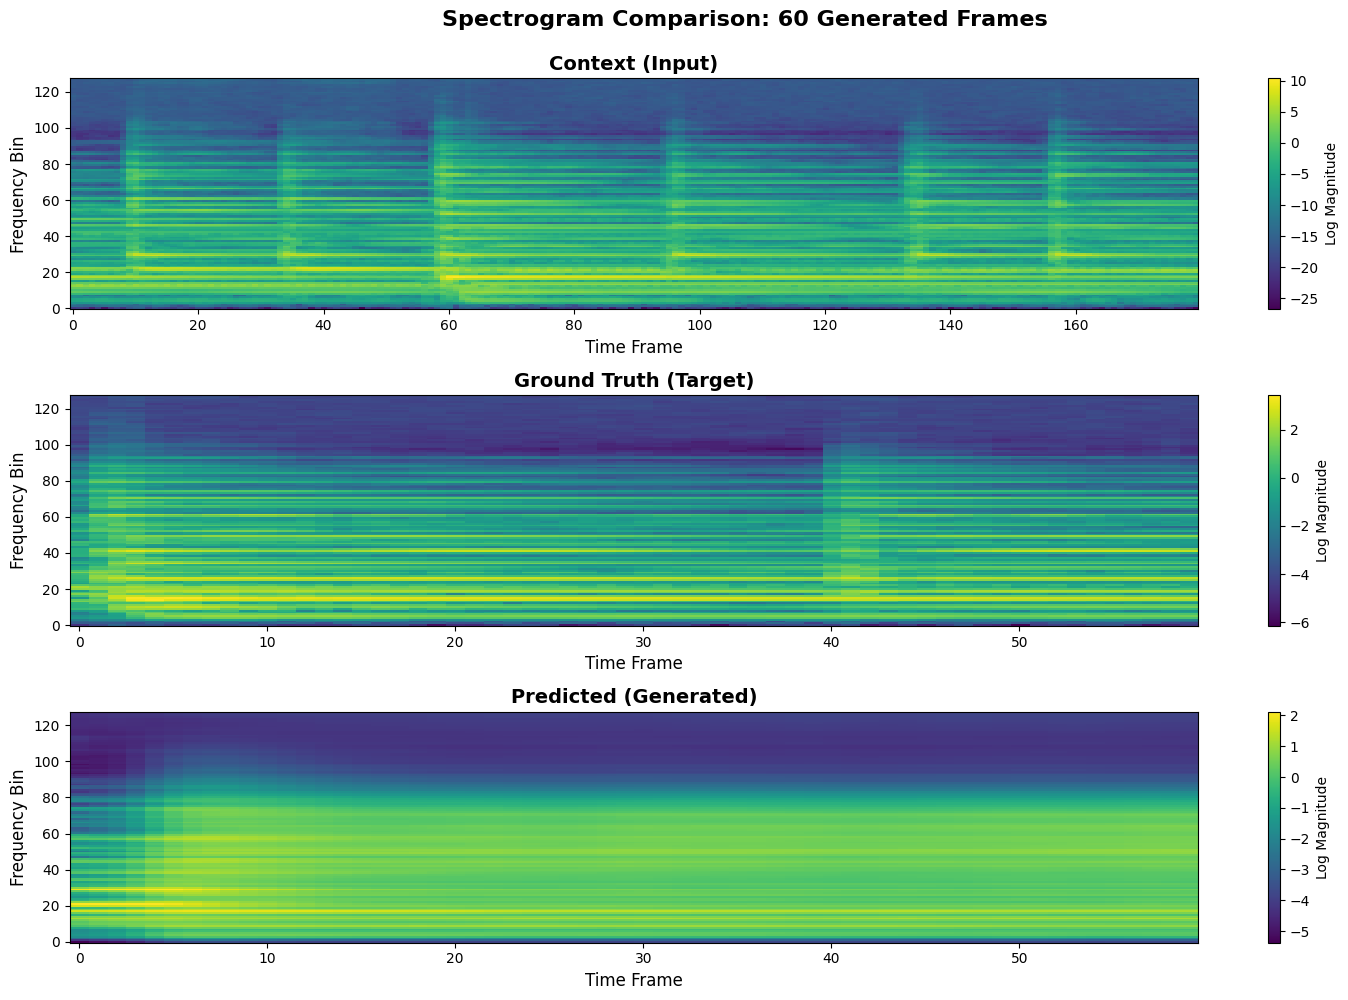

Converting spectrograms to audio...
Saved generated audio to generated_outputs/generated_audio.wav
Saved ground truth audio to generated_outputs/ground_truth_audio.wav
Saved context audio to generated_outputs/context_audio.wav

AUDIO COMPARISON

1. Context Audio (Input):



2. Ground Truth Audio (Target):



3. Generated Audio (Predicted):



All outputs saved to: /content/generated_outputs


In [48]:
google_drive_url = "https://drive.google.com/file/d/1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp/view?usp=sharing"
# context = test_tensor[0:1, 0:150, :]  # First 150 frames
# ground_truth = test_tensor[0, 150:210, :]  # Next 60 frames

context, ground_truth = get_test_sample(
    test_tensor=test_tensor,
    sample_idx=2959,      # Which sample (0, 1, 2, ...)
    context_size=180, # Context frames (fixed at 150 for your benchmark)
    num_frames=100,    # How many frames to generate (20, 60, 100, etc.)
    start_frame=0     # Starting frame (usually 0)
)

results = load_model_and_generate(
    checkpoint_path_or_url=google_drive_url,
    context=context,
    ground_truth=ground_truth,
    num_frames=60,
    visualize=True,
    save_audio=True
)

In [29]:


def compute_all_metrics(predictions, ground_truth, return_per_frame=False):
    """
    Compute comprehensive metrics for spectrogram prediction.

    Args:
        predictions: Predicted spectrograms (batch, num_frames, freq_bins) or (num_frames, freq_bins)
        ground_truth: Ground truth spectrograms (batch, num_frames, freq_bins) or (num_frames, freq_bins)
        return_per_frame: If True, also return per-frame metrics

    Returns:
        Dictionary of metrics
    """
    # Ensure same shape
    if predictions.dim() == 2:
        predictions = predictions.unsqueeze(0)
    if ground_truth.dim() == 2:
        ground_truth = ground_truth.unsqueeze(0)

    # Handle different lengths (ground truth may be shorter)
    min_frames = min(predictions.shape[1], ground_truth.shape[1])
    predictions = predictions[:, :min_frames, :]
    ground_truth = ground_truth[:, :min_frames, :]

    # Flatten for some metrics
    pred_flat = predictions.flatten()
    target_flat = ground_truth.flatten()

    # 1. MSE (Mean Squared Error)
    mse_tensor = torch.mean((predictions - ground_truth) ** 2) # Keep as tensor
    mse = mse_tensor.item() # Convert to float for storage

    # 3. RMSE (Root Mean Squared Error)
    rmse = torch.sqrt(mse_tensor).item() # Apply sqrt to tensor, then convert to float

    # 2. MAE (Mean Absolute Error)
    mae = torch.mean(torch.abs(predictions - ground_truth)).item()

    # 4. R² Score (Coefficient of Determination)
    ss_res = torch.sum((target_flat - pred_flat) ** 2)
    ss_tot = torch.sum((target_flat - torch.mean(target_flat)) ** 2)
    r2 = (1 - ss_res / (ss_tot + 1e-8)).item()

    # 5. Correlation (Pearson Correlation Coefficient)
    pred_centered = pred_flat - torch.mean(pred_flat)
    target_centered = target_flat - torch.mean(target_flat)
    correlation = (torch.sum(pred_centered * target_centered) /
                  (torch.sqrt(torch.sum(pred_centered ** 2) * torch.sum(target_centered ** 2)) + 1e-8)).item()

    # 6. Frame Accuracy (percentage of frames within threshold)
    data_range = target_flat.max() - target_flat.min()
    threshold = 0.1 * data_range  # 10% of data range
    frame_mse = torch.mean((predictions - ground_truth) ** 2, dim=-1)  # (batch, num_frames)
    frame_accuracy = (frame_mse < threshold).float().mean().item()

    # 7. Log Spectral Distance (LSD) - Audio-specific metric
    pred_log = torch.log10(torch.clamp(predictions, min=1e-10))
    target_log = torch.log10(torch.clamp(ground_truth, min=1e-10))
    lsd = torch.sqrt(torch.mean((pred_log - target_log) ** 2)).item()

    # 8. Cosine Similarity
    pred_norm = torch.norm(pred_flat)
    target_norm = torch.norm(target_flat)
    cosine_sim = (torch.sum(pred_flat * target_flat) / (pred_norm * target_norm + 1e-8)).item()

    metrics = {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Correlation': correlation,
        'Frame Accuracy (10%)': frame_accuracy,
        'Log Spectral Distance': lsd,
        'Cosine Similarity': cosine_sim
    }

    if return_per_frame:
        # Per-frame MSE
        per_frame_mse = torch.mean((predictions - ground_truth) ** 2, dim=-1).mean(dim=0)  # (num_frames,)
        metrics['Per-Frame MSE'] = per_frame_mse.cpu().numpy()

        # Error accumulation
        cumulative_error = torch.cumsum(per_frame_mse, dim=0)
        metrics['Cumulative Error'] = cumulative_error.cpu().numpy()
        metrics['Error Growth Rate'] = (cumulative_error[-1] / per_frame_mse.shape[0]).item()

    return metrics


def print_metrics(metrics, title="Evaluation Metrics"):
    """Pretty print metrics dictionary."""
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")

    for key, value in metrics.items():
        if isinstance(value, (int, float)):
            if 'Accuracy' in key or 'Similarity' in key or 'Correlation' in key or 'R²' in key:
                print(f"{key:25s}: {value:.4f} ({value*100:.2f}%)")
            elif 'Distance' in key:
                print(f"{key:25s}: {value:.4f} dB")
            else:
                print(f"{key:25s}: {value:.6f}")
        else:
            print(f"{key:25s}: {type(value).__name__} (use return_per_frame=True to see)")

    print(f"{'='*60}\n")

In [30]:
def evaluate_all_models(
    model_checkpoints: dict,  # {'small': path_or_url, 'medium': path_or_url, 'large': path_or_url}
    test_tensor: torch.Tensor,
    context_size: int = 150,
    num_frames: int = 60,
    num_samples: Optional[int] = None,  # None = use all, or specify number
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    visualize: bool = True,
    save_path: Optional[str] = None
):
    """
    Evaluate all models on test set and compare metrics.
    Supports both local file paths and Google Drive links!

    Args:
        model_checkpoints: Dict mapping model names to checkpoint paths or Google Drive URLs
            Example: {
                'small': 'checkpoints/autoregressive_small_best.pt',
                'medium': 'https://drive.google.com/file/d/1NzmJMby76uQJwRE5Hi4svXr7lkeNp4iX/view?usp=drive_link',
                'large': 'checkpoints/autoregressive_large_best.pt'
            }
        test_tensor: Test tensor of shape (N, T, F)
        context_size: Context size to use
        num_frames: Number of frames to generate
        num_samples: Number of samples to evaluate (None = all)
        device: Device to run on
        visualize: Whether to create comparison plots
        save_path: Optional path to save comparison plot

    Returns:
        Dictionary with metrics for each model
    """
    # Select samples
    if num_samples is None:
        sample_indices = list(range(len(test_tensor)))
        print(f"Evaluating on ALL {len(sample_tensor)} test samples...")
    else:
        import random
        sample_indices = random.sample(range(len(test_tensor)), min(num_samples, len(test_tensor)))
        print(f"Evaluating on {len(sample_indices)} randomly sampled test samples...")

    all_metrics = {}

    for model_name, checkpoint_path_or_url in model_checkpoints.items():
        print(f"\n{'='*60}")
        print(f"Evaluating {model_name.upper()} model...")
        print(f"{'='*60}")

        # Handle Google Drive links
        if "drive.google.com" in checkpoint_path_or_url or len(checkpoint_path_or_url) == 33:
            # Download from Google Drive
            file_id = extract_google_drive_id(checkpoint_path_or_url)
            temp_dir = Path(tempfile.gettempdir()) / "audio_predict_models"
            temp_dir.mkdir(exist_ok=True)
            checkpoint_path = temp_dir / f"{file_id}.pt"

            if not checkpoint_path.exists():
                print(f"Downloading {model_name} model from Google Drive (ID: {file_id})...")
                download_from_google_drive(file_id, str(checkpoint_path))
            else:
                print(f"Using cached {model_name} model: {checkpoint_path}")
        else:
            checkpoint_path = checkpoint_path_or_url

        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location=device)
        config = checkpoint['config']

        # Create model with same max_seq_len as training
        context_size_config = config.get('context_size', context_size)
        target_frames = config.get('target_frames', 102)
        training_max_seq_len = context_size_config + target_frames

        model = AutoregressiveTransformer(
            input_dim=config['input_dim'],
            d_model=config['d_model'],
            num_heads=config['num_heads'],
            num_layers=config['num_layers'],
            d_ff=config['d_ff'],
            max_seq_len=training_max_seq_len,
            dropout=0.1,
        ).to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        # Normalize test tensor
        if 'normalization_stats' in config:
            stats = config['normalization_stats']
            # Move stats to CPU before using them for normalization
            if isinstance(stats['mean'], torch.Tensor): # Check if it's a tensor before moving
                stats['mean'] = stats['mean'].to('cpu')
            if isinstance(stats['std'], torch.Tensor): # Check if it's a tensor before moving
                stats['std'] = stats['std'].to('cpu')
            if stats['method'] == 'standardize':
                test_norm = (test_tensor - stats['mean']) / stats['std']
            elif stats['method'] == 'minmax':
                test_min = stats['min'].to('cpu') if isinstance(stats['min'], torch.Tensor) else stats['min']
                test_max = stats['max'].to('cpu') if isinstance(stats['max'], torch.Tensor) else stats['max']
                test_norm = (test_tensor - test_min) / (test_max - test_min + 1e-8)
            else:
                test_norm = test_tensor
        else:
            test_norm = test_tensor

        # Collect all predictions and ground truths
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for idx in tqdm(sample_indices, desc=f"{model_name}", leave=False):
                # Get context and ground truth
                context = test_norm[idx:idx+1, :context_size, :].to(device)
                ground_truth = test_tensor[idx, context_size:context_size+num_frames, :]

                # Generate
                generated_norm = model.generate(context, num_frames=num_frames)

                # Denormalize
                if 'normalization_stats' in config:
                    stats = config['normalization_stats']
                    # Ensure stats are on CPU for denormalization if they were moved there
                    if isinstance(stats['mean'], torch.Tensor):
                        stats['mean'] = stats['mean'].to('cpu')
                    if isinstance(stats['std'], torch.Tensor):
                        stats['std'] = stats['std'].to('cpu')
                    if stats['method'] == 'standardize':
                        generated = generated_norm * stats['std'] + stats['mean']
                    elif stats['method'] == 'minmax':
                        gen_min = stats['min'].to('cpu') if isinstance(stats['min'], torch.Tensor) else stats['min']
                        gen_max = stats['max'].to('cpu') if isinstance(stats['max'], torch.Tensor) else stats['max']
                        generated = generated_norm * (gen_max - gen_min) + gen_min
                    else:
                        generated = generated_norm
                else:
                    generated = generated_norm

                generated = generated.cpu().squeeze(0)

                # Handle different lengths
                min_len = min(generated.shape[0], ground_truth.shape[0])
                all_preds.append(generated[:min_len])
                all_targets.append(ground_truth[:min_len])

        # Concatenate and compute metrics
        all_preds = torch.cat(all_preds, dim=0).unsqueeze(0)  # (1, total_frames, 128)
        all_targets = torch.cat(all_targets, dim=0).unsqueeze(0)  # (1, total_frames, 128)

        metrics = compute_all_metrics(all_preds, all_targets, return_per_frame=True)
        all_metrics[model_name] = metrics

        print(f"\n{model_name.upper()} Results:")
        print_metrics(metrics, title=f"{model_name.upper()} Model")

    # Visualize comparison
    if visualize:
        metrics_to_plot = ['MSE', 'Frame Accuracy (10%)', 'R²', 'Correlation', 'Log Spectral Distance']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        models = list(all_metrics.keys())
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

        for idx, metric in enumerate(metrics_to_plot):
            ax = axes[idx]
            values = [all_metrics[model][metric] for model in models]

            bars = ax.bar(models, values, color=colors[:len(models)], alpha=0.7, edgecolor='black', linewidth=1.5)
            ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
            ax.set_ylabel('Value', fontsize=12)
            ax.grid(axis='y', alpha=0.3, linestyle='--')

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Per-frame MSE plot (6th subplot)
        ax = axes[5]
        for i, model in enumerate(models):
            per_frame_mse = all_metrics[model]['Per-Frame MSE']
            frames = np.arange(len(per_frame_mse))
            ax.plot(frames, per_frame_mse, label=model, color=colors[i], linewidth=2, marker='o', markersize=3)
        ax.set_title('Per-Frame MSE (Error Over Time)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Frame Index', fontsize=12)
        ax.set_ylabel('MSE', fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3, linestyle='--')

        plt.suptitle('Model Comparison: All Metrics', fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"\nComparison plot saved to: {save_path}")
        plt.show()

    return all_metrics

Evaluating on 2000 randomly sampled test samples...

Evaluating SMALL model...
Using cached small model: /tmp/audio_predict_models/1O_A0kRCV-zSVR-IhSUnY6e9-0jRSvH29.pt



SMALL Results:

SMALL Model
MSE                      : 3.316980
MAE                      : 1.313491
RMSE                     : 1.821258
R²                       : 0.3006 (30.06%)
Correlation              : 0.6934 (69.34%)
Frame Accuracy (10%)     : 0.4559 (45.59%)
Log Spectral Distance    : 3.6105 dB
Cosine Similarity        : 0.8519 (85.19%)
Per-Frame MSE            : ndarray (use return_per_frame=True to see)
Cumulative Error         : ndarray (use return_per_frame=True to see)
Error Growth Rate        : 3.316980


Evaluating MEDIUM model...
Using cached medium model: /tmp/audio_predict_models/1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp.pt



MEDIUM Results:

MEDIUM Model
MSE                      : 3.100687
MAE                      : 1.235804
RMSE                     : 1.760877
R²                       : 0.3462 (34.62%)
Correlation              : 0.7147 (71.47%)
Frame Accuracy (10%)     : 0.5319 (53.19%)
Log Spectral Distance    : 3.6908 dB
Cosine Similarity        : 0.8594 (85.94%)
Per-Frame MSE            : ndarray (use return_per_frame=True to see)
Cumulative Error         : ndarray (use return_per_frame=True to see)
Error Growth Rate        : 3.100687


Evaluating LARGE model...
Using cached large model: /tmp/audio_predict_models/1GGPa-YfAUU_VEo97fJiq6LYQYI3jeqyD.pt



LARGE Results:

LARGE Model
MSE                      : 3.388778
MAE                      : 1.332757
RMSE                     : 1.840863
R²                       : 0.2854 (28.54%)
Correlation              : 0.6665 (66.65%)
Frame Accuracy (10%)     : 0.4449 (44.49%)
Log Spectral Distance    : 4.1604 dB
Cosine Similarity        : 0.8150 (81.50%)
Per-Frame MSE            : ndarray (use return_per_frame=True to see)
Cumulative Error         : ndarray (use return_per_frame=True to see)
Error Growth Rate        : 3.388778


Comparison plot saved to: model_comparison.png


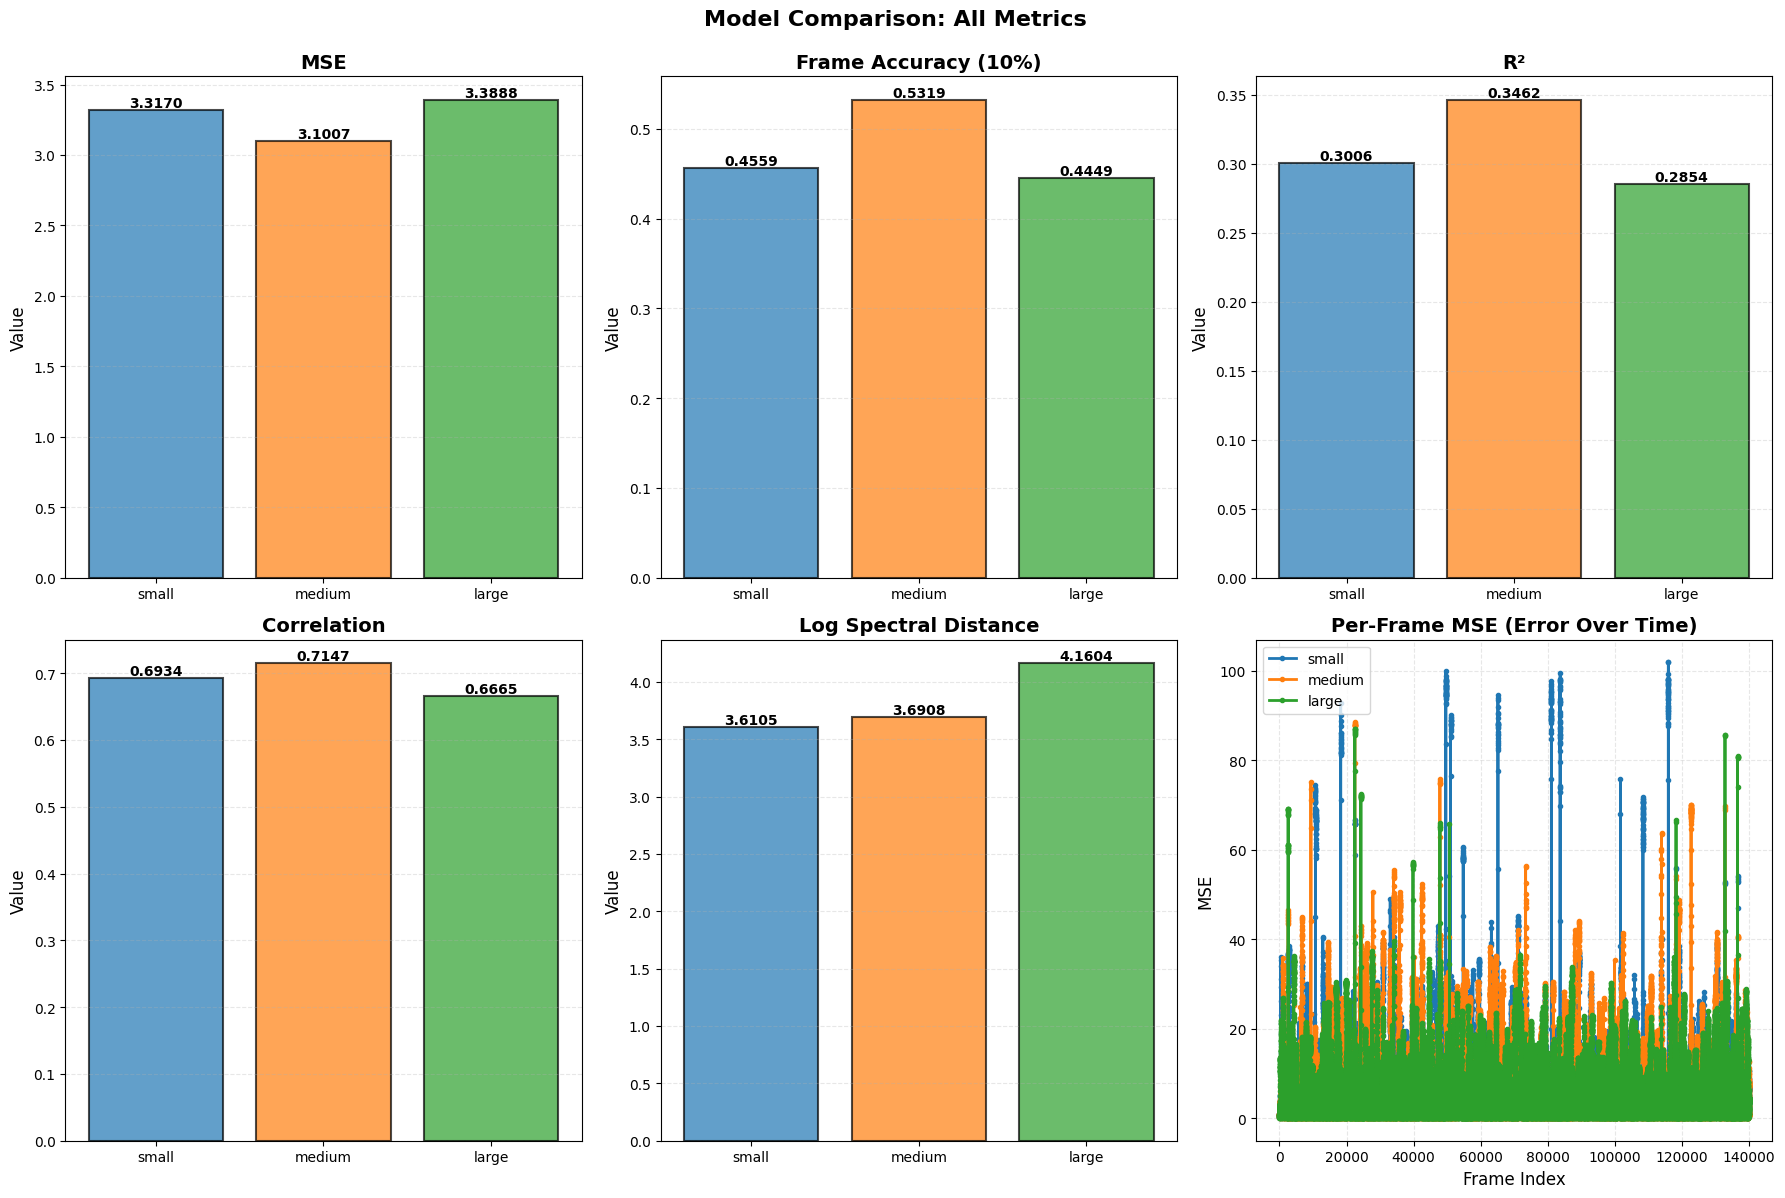

In [49]:
# Example usage:
model_checkpoints = {
    'small': 'https://drive.google.com/file/d/1O_A0kRCV-zSVR-IhSUnY6e9-0jRSvH29/view?usp=drive_link',
    'medium': 'https://drive.google.com/file/d/1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp/view?usp=sharing',
    'large': 'https://drive.google.com/file/d/1GGPa-YfAUU_VEo97fJiq6LYQYI3jeqyD/view?usp=sharing'
}

results = evaluate_all_models(
    model_checkpoints=model_checkpoints,
    test_tensor=test_tensor,
    context_size=150,
    num_frames=70,
    num_samples=2000,  # Use all test samples
    visualize=True,
    save_path="model_comparison.png"
)


In [44]:
"""
Quick script to check best validation loss for each model from checkpoints.
This extracts the val_loss saved in each checkpoint file.
"""

import torch
import sys
from pathlib import Path
import tempfile

def extract_google_drive_id(url):
    """Extract file ID from Google Drive URL."""
    if '/file/d/' in url:
        return url.split('/file/d/')[1].split('/')[0]
    elif 'id=' in url:
        return url.split('id=')[1].split('&')[0]
    else:
        return url  # Assume it's already an ID

def download_from_google_drive(file_id, destination):
    """Download file from Google Drive using gdown."""
    try:
        import gdown
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, destination, quiet=False)
    except ImportError:
        print("ERROR: gdown not installed. Install with: pip install gdown")
        sys.exit(1)

def get_checkpoint_info(checkpoint_path_or_url, model_name):
    """Extract training info from a checkpoint."""
    # Handle Google Drive links
    if "drive.google.com" in checkpoint_path_or_url or len(checkpoint_path_or_url) == 33:
        file_id = extract_google_drive_id(checkpoint_path_or_url)
        temp_dir = Path(tempfile.gettempdir()) / "audio_predict_models"
        temp_dir.mkdir(exist_ok=True)
        checkpoint_path = temp_dir / f"{file_id}.pt"

        if not checkpoint_path.exists():
            print(f"Downloading {model_name} model from Google Drive...")
            download_from_google_drive(file_id, str(checkpoint_path))
        else:
            print(f"Using cached {model_name} model")
    else:
        checkpoint_path = checkpoint_path_or_url
        if not Path(checkpoint_path).exists():
            print(f"ERROR: Checkpoint not found: {checkpoint_path}")
            return None

    # Load checkpoint
    try:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        config = checkpoint.get('config', {})

        info = {
            'model_name': model_name,
            'val_loss': checkpoint.get('val_loss', None),
            'epoch': checkpoint.get('epoch', None),
            'train_loss': checkpoint.get('train_loss', None),
            'context_size': config.get('context_size', 'N/A'),
            'target_frames': config.get('target_frames', 'N/A'),
            'learning_rate': config.get('learning_rate', 'N/A'),
            'size': config.get('size', 'N/A'),
        }
        return info
    except Exception as e:
        print(f"ERROR loading {model_name}: {e}")
        return None

def print_training_summary(model_checkpoints):
    """Print a nice summary table of training results."""
    print("\n" + "="*80)
    print("TRAINING RESULTS SUMMARY")
    print("="*80)

    results = []
    for model_name, checkpoint_path in model_checkpoints.items():
        info = get_checkpoint_info(checkpoint_path, model_name)
        if info:
            results.append(info)

    if not results:
        print("No valid checkpoints found!")
        return

    # Print table header
    print(f"\n{'Model':<10} {'Best Val Loss':<15} {'Best Epoch':<12} {'Train Loss':<15} {'Context':<10} {'Target':<10}")
    print("-" * 80)

    # Print each model's results
    for info in results:
        val_loss = f"{info['val_loss']:.6f}" if info['val_loss'] is not None else "N/A"
        epoch = f"{info['epoch']}" if info['epoch'] is not None else "N/A"
        train_loss = f"{info['train_loss']:.6f}" if info['train_loss'] is not None else "N/A"
        context = f"{info['context_size']}" if info['context_size'] != 'N/A' else "N/A"
        target = f"{info['target_frames']}" if info['target_frames'] != 'N/A' else "N/A"

        print(f"{info['model_name']:<10} {val_loss:<15} {epoch:<12} {train_loss:<15} {context:<10} {target:<10}")

    # Find best model
    valid_results = [r for r in results if r['val_loss'] is not None]
    if valid_results:
        best_model = min(valid_results, key=lambda x: x['val_loss'])
        print("\n" + "="*80)
        print(f"🏆 BEST MODEL (Lowest Validation Loss): {best_model['model_name'].upper()}")
        print(f"   Validation Loss: {best_model['val_loss']:.6f}")
        print(f"   Achieved at Epoch: {best_model['epoch']}")
        print("="*80)

        # Compare models
        print("\n📊 COMPARISON:")
        for info in valid_results:
            if info['val_loss'] is not None:
                diff = info['val_loss'] - best_model['val_loss']
                if diff > 0:
                    print(f"   {info['model_name']:>6}: {info['val_loss']:.6f} (+{diff:.6f} worse than best)")
                else:
                    print(f"   {info['model_name']:>6}: {info['val_loss']:.6f} (BEST)")

    # Check for overfitting indicators
    print("\n🔍 OVERFITTING CHECK:")
    for info in valid_results:
        if info['train_loss'] is not None and info['val_loss'] is not None:
            gap = info['val_loss'] - info['train_loss']
            if gap > 0.1:
                print(f"   ⚠️  {info['model_name']:>6}: Large gap (val_loss - train_loss = {gap:.6f})")
                print(f"      This suggests possible overfitting!")
            elif gap < 0:
                print(f"   ✅ {info['model_name']:>6}: Val loss better than train (gap = {gap:.6f})")
            else:
                print(f"   ✅ {info['model_name']:>6}: Gap is reasonable (gap = {gap:.6f})")

    print("\n" + "="*80)






In [45]:
model_checkpoints = {
    'small': 'https://drive.google.com/file/d/1MV_-fBo-EoUmQ2j_R6WoYKxKeHjziJ9j/view?usp=sharing',
    'medium': 'https://drive.google.com/file/d/1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp/view?usp=sharing',
    'large': 'https://drive.google.com/file/d/1GGPa-YfAUU_VEo97fJiq6LYQYI3jeqyD/view?usp=sharing'
}


print_training_summary(model_checkpoints)


TRAINING RESULTS SUMMARY
Using cached small model


Downloading...
From: https://drive.google.com/uc?id=1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp
To: /tmp/audio_predict_models/1Xx35OoSRcph9YKRjeXAgKmsFI6bUO8vp.pt
100%|██████████| 14.6M/14.6M [00:00<00:00, 167MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1GGPa-YfAUU_VEo97fJiq6LYQYI3jeqyD
From (redirected): https://drive.google.com/uc?id=1GGPa-YfAUU_VEo97fJiq6LYQYI3jeqyD&confirm=t&uuid=42671e3a-801a-4af4-b897-560472a8c83e
To: /tmp/audio_predict_models/1GGPa-YfAUU_VEo97fJiq6LYQYI3jeqyD.pt
100%|██████████| 107M/107M [00:00<00:00, 204MB/s] 


Model      Best Val Loss   Best Epoch   Train Loss      Context    Target    
--------------------------------------------------------------------------------
small      0.017991        25           N/A             150        102       
medium     0.017815        34           N/A             150        102       
large      0.016511        33           N/A             150        102       

🏆 BEST MODEL (Lowest Validation Loss): LARGE
   Validation Loss: 0.016511
   Achieved at Epoch: 33

📊 COMPARISON:
    small: 0.017991 (+0.001480 worse than best)
   medium: 0.017815 (+0.001304 worse than best)
    large: 0.016511 (BEST)

🔍 OVERFITTING CHECK:



**Reasoning**:
To copy the comparison plot to Google Drive, I need to define the source and destination paths and then use `shutil.copy`.



**Reasoning**:
The subtask requires installing the `torchcodec` library. Running `!pip install torchcodec` will install the necessary package.



# Task
Modify the `train_autoregressive_transformer` function to include a `filename_tag` parameter, update its internal logic to automatically include `size`, `context_size`, `target_frames`, and the new `filename_tag` in the default saved model filename. Then, modify the training call to `train_autoregressive_transformer` to use `filename_tag='_modified_params'` and remove the `model_filename` parameter. Finally, update the model copying cell to reflect this new filename structure, retrain the model with the updated naming convention, and copy it to Google Drive to confirm the new naming convention is correctly applied.

## Modify train_autoregressive_transformer for filename tag

### Subtask:
Add a `filename_tag` parameter to the `train_autoregressive_transformer` function and update the logic to include `size`, `context_size`, `target_frames`, and `filename_tag` in the default saved model filename.


**Reasoning**:
I need to modify the `train_autoregressive_transformer` function in cell `jnitFjX43rcg` to add a `filename_tag` parameter and update the `best_path` naming convention as per the instructions.

